# SAE Topological Recoverability

Visualization and exploration notebook. All library code lives in `sae_topology/`.

Run the full headless validation with:
```
python validate.py --no-plot
```

**Sections**
1. DGP Explorer — point cloud geometry
2. PH Validation Suite — Betti-number checks + persistence diagrams + barcodes
3. Reference PH — low-noise ground-truth diagrams for all four topologies
4. T1/T2 Score — sanity check with point-cloud and PH visualizations

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sae_topology.dgp import make_dgp, Torus
from sae_topology.ph.validate import run_validation_suite, VALIDATION_CONFIGS
from sae_topology.ph.reference import GROUND_TRUTH_BETTI, compute_reference_ph, verify_reference_ph
from sae_topology.ph.scores import compute_t1_t2_score_for_sae
from sae_topology.analysis.plot import (
    plot_dgp_samples,
    plot_persistence_diagrams,
    plot_barcodes,
    plot_reference_h1_grid,
    plot_reference_diagrams,
    plot_t1t2_comparison,
)


## 1 · DGP Explorer — Point Cloud Geometry

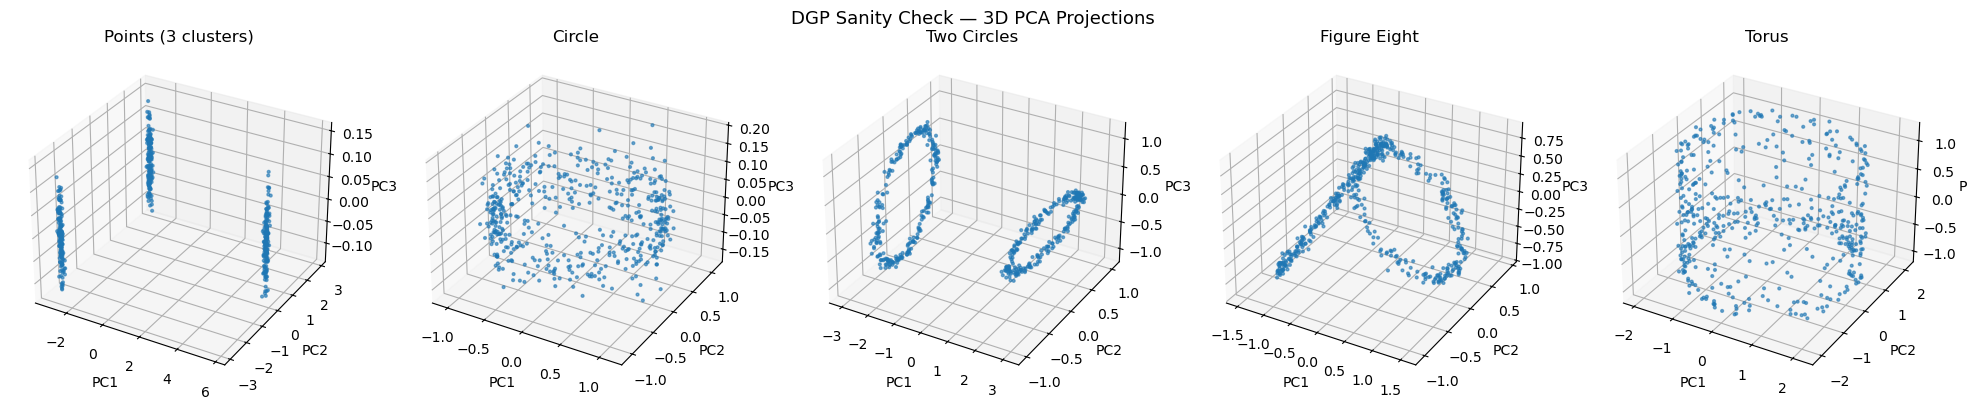

In [2]:
# ── Configurable parameters — edit and re-run ─────────────────────────────
d      = 8      # ambient dimension
sigma  = 0.05   # noise std dev
N      = 500    # sample size per topology
seed   = 42

fig = plot_dgp_samples(list(GROUND_TRUTH_BETTI.keys()), make_dgp,
                       d=d, sigma=sigma, N=N, seed=seed, pca_dim=3)
plt.show()

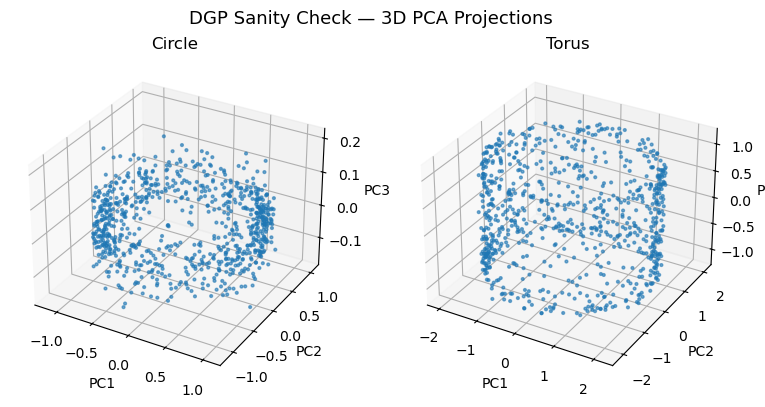

In [3]:
# 3-D PCA for torus — two-torus structure visible in PC1/PC2/PC3
fig = plot_dgp_samples(["circle", "torus"], make_dgp, d=8, sigma=0.05, N=800, pca_dim=3)
plt.show()


## 2 · PH Validation Suite

Checks that `ripser` recovers the correct Betti numbers for five reference
topologies.  The noise floor `min_persistence = max(0.1·diam, 3·σ·√d)` is
critical at high `d` and prevents ambient noise from inflating H₀ counts.

In [4]:
# Run validation — prints PASS/FAIL for each topology
# results = run_validation_suite(d=8, sigma=0.05, N=500)

In [5]:
# Persistence diagram grid (birth vs death for H₀ and H₁)
# fig = plot_persistence_diagrams(results, VALIDATION_CONFIGS)
# plt.show()

In [6]:
# Barcode plot for one topology — faint bars are below the noise floor
# ── Change 'topo' to inspect a different case ─────────────────────────────
# topo = 'circle'   # options: 'line_segment', 'circle', 'sphere',
#                   #          'two_circles', 'figure_eight'

# r = results[topo]
# fig = plot_barcodes(r['ph']['dgms'],
#                     min_persistence=r['min_persistence'],
#                     title=f'{topo} — persistence barcodes')
# plt.show()

## 3 · Reference PH — Low-Noise Ground Truth

Large (N=1000), low-noise (σ=0.02) samples used as ground-truth diagrams
for bottleneck-distance comparisons in Stage 4.

In [ ]:
np.random.seed(1)
ref_phs = {t: compute_reference_ph(t) for t in GROUND_TRUTH_BETTI}
verify_reference_ph(ref_phs)

In [ ]:
# Persistence diagrams for all DGP topologies (H₀, H₁, H₂ where applicable)
fig = plot_reference_diagrams(ref_phs)
plt.show()


## 4 · T1/T2 Score — Sanity Check

- **T1 toy**: decoder atoms arranged on a unit circle, sparse codes are
  Gaussian noise → topology lives in atoms → expected score ≈ 1.
- **T2 toy**: decoder atoms on a line segment (no H₁), sparse codes arranged
  on a circle → topology lives in codes → expected score ≈ 0.

`min_persistence=0.5` filters spurious H₁ bars that arise from the boundary
of a Gaussian distribution when projected to 4D PCA space.

In [ ]:
np.random.seed(7)
d_toy, m, n = 8, 64, 500

# ── T1 toy: circle in atom space ──────────────────────────────────────────
thetas = np.linspace(0, 2 * np.pi, m, endpoint=False)
u = np.zeros(d_toy); u[0] = 1.0
v = np.zeros(d_toy); v[1] = 1.0
atoms_t1  = np.outer(np.cos(thetas), u) + np.outer(np.sin(thetas), v)
atoms_t1 += np.random.randn(m, d_toy) * 0.02
atoms_t1 /= np.linalg.norm(atoms_t1, axis=1, keepdims=True)
codes_t1  = np.random.randn(n, m)

# ── T2 toy: circle in code space ──────────────────────────────────────────
atoms_t2 = np.zeros((m, d_toy))
atoms_t2[:, 0] = np.linspace(0, 1, m)          # line segment — no H₁
thetas_c = np.random.uniform(0, 2 * np.pi, n)
codes_t2 = np.zeros((n, m))
codes_t2[:, 0] = np.cos(thetas_c) + 1.0
codes_t2[:, 1] = np.sin(thetas_c) + 1.0
codes_t2 += np.random.randn(n, m) * 0.01

# ── Compute scores ────────────────────────────────────────────────────────
min_pers = 0.5    # filters boundary H₁ from Gaussian codes in PCA space
r1 = compute_t1_t2_score_for_sae(atoms_t1, codes_t1, pca_dim=4,
                                   min_persistence=min_pers)
r2 = compute_t1_t2_score_for_sae(atoms_t2, codes_t2, pca_dim=4,
                                   min_persistence=min_pers)

s1 = f"{r1['score']:.3f}" if not np.isnan(r1['score']) else 'nan'
s2 = f"{r2['score']:.3f}" if not np.isnan(r2['score']) else 'nan'
print(f"T1 toy  rho_T1={r1['rho_t1']:.3f}  score={s1}  (expect ~1)")
print(f"T2 toy  rho_T2={r2['rho_t2']:.3f}  score={s2}  (expect ~0)")

In [ ]:
# Point-cloud scatters (2D PCA) + persistence diagrams side by side
fig = plot_t1t2_comparison(atoms_t1, codes_t1, atoms_t2, codes_t2,
                            r1, r2, min_persistence=min_pers)
plt.show()

## 5 · Stage 2 — SAE Training

Train a single SAE on a DGP topology and inspect the T1/T2 score and training health.

Edit the parameters block and re-run all three cells.

In [20]:
# ── Parameters — edit and re-run ────────────────────────────────────────────
topology = "points"
arch     = "topk"   # "relu_l1" | "topk" | "jumprelu"
d        = 8
sigma    = 0.05
m        = 64           # SAE width (number of atoms)
seed     = 0

from sae_topology.saes import SAETrainConfig
from sae_topology.experiments import run_sae_experiment
from sae_topology.analysis.plot import plot_training_curves

cfg    = SAETrainConfig(arch=arch, d_in=d, d_sae=m, seed=seed)
result = run_sae_experiment(topology, cfg, dict(d=d, sigma=sigma))

score  = result.t1t2["score"]
live   = result.t1t2["n_live_atoms"]
rho_t1 = result.t1t2["rho_t1"]
rho_t2 = result.t1t2["rho_t2"]
print(f"score={score:.3f}  live_atoms={live}/{m}  rho_T1={rho_t1:.3f}  rho_T2={rho_t2:.3f}")

score=nan  live_atoms=22/64  rho_T1=nan  rho_T2=nan


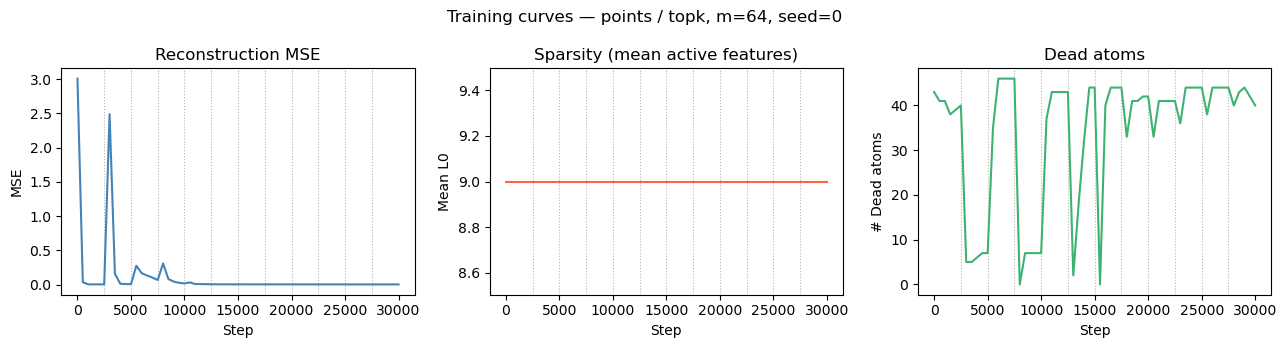

In [21]:
# Training diagnostics: MSE, mean L0, dead-atom count vs. step
fig = plot_training_curves(result)

Text(0.5, 0.98, 'points / topk m=64 | score=nan')

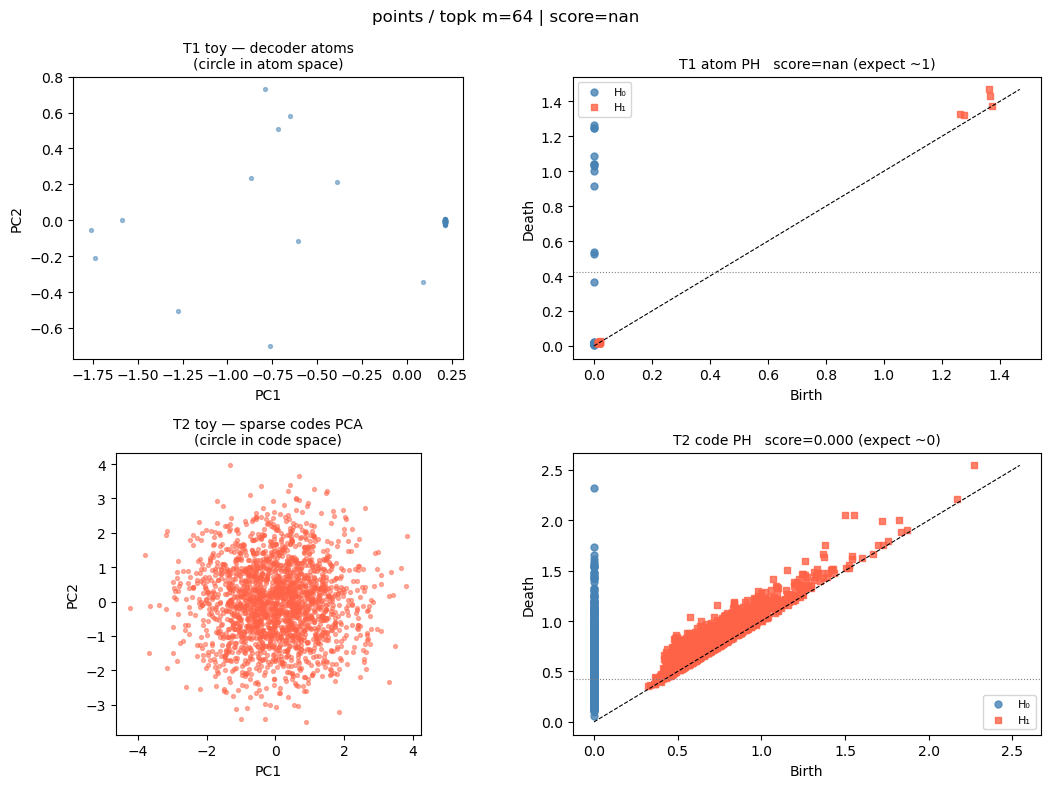

In [22]:
# T1/T2 persistence diagrams for this SAE run
# Uses the existing plot_t1t2_comparison by passing the SAE atoms+codes as toy data
from sae_topology.ph import compute_t1_t2_score_for_sae
import math

min_pers = 3.0 * sigma * math.sqrt(d)

# Build a T1 reference: same atoms, Gaussian codes (topology only in atoms)
import numpy as np
r_t1ref = compute_t1_t2_score_for_sae(
    result.atoms, np.random.randn(*result.codes.shape),
    pca_dim=cfg.pca_dim, min_persistence=min_pers
)

fig = plot_t1t2_comparison(
    result.atoms, result.codes,   # actual SAE
    result.atoms, np.random.randn(*result.codes.shape),  # reference
    result.t1t2, r_t1ref,
    min_persistence=min_pers,
)
fig.suptitle(f"{topology} / {arch} m={m} | score={score:.3f}", fontsize=12)

## 6 · Stage 3 — Cross-Topology Architecture Comparison

Sweep `relu_l1` (l1_coeff=2e-2) and `topk` (k=9) across **circle**, **two_circles**, and **figure_eight** at m=64, 3 seeds each (18 runs total).

**Hypothesis:** relu_l1 → score ≈ 1.0 (T1-dominant) on all three topologies; topk → score < 0.5 (T2-permissive).

In [3]:
from pathlib import Path
from sae_topology.experiments import architecture_sweep
from sae_topology.saes import SAETrainConfig

d, sigma, m = 8, 0.05, 64
dgp_params  = dict(d=d, sigma=sigma)

base_relu = SAETrainConfig(arch="relu_l1", d_in=d, d_sae=m, l1_coeff=2e-2)
base_topk = SAETrainConfig(arch="topk",    d_in=d, d_sae=m, k=9)

stage3_results = architecture_sweep(
    topologies=["circle", "two_circles", "figure_eight"],
    archs=["relu_l1", "topk"],
    widths=[m],
    n_seeds=3,
    base_configs={"relu_l1": base_relu, "topk": base_topk},
    dgp_params=dgp_params,
    n_jobs=16,
    results_dir=Path("results/stage3"),
)
print(f"Completed {len(stage3_results)} runs.")

Completed 18 runs.


In [5]:
import pandas as pd

rows = []
for r in stage3_results:
    rows.append({
        "topology":   r.topology,
        "arch":       r.arch,
        "seed":       r.seed,
        "score":      r.t1t2["score"],
        "rho_t1":     r.t1t2["rho_t1"],
        "rho_t2":     r.t1t2["rho_t2"],
        "live_atoms": r.t1t2["n_live_atoms"],
        "mean_l0":    r.metrics["mean_l0"][-1] if r.metrics["mean_l0"] else float("nan"),
    })
df = pd.DataFrame(rows)
summary = df.groupby(["topology", "arch"])["score"].agg(["mean", "std"]).round(3)
print(summary.to_string())
print()
print("Per-run detail:")
print(df[["topology","arch","seed","score","live_atoms","mean_l0"]].to_string(index=False))

                       mean    std
topology     arch                 
circle       relu_l1  1.000  0.000
             topk     0.201  0.079
figure_eight relu_l1  0.031  0.010
             topk     0.000  0.000
two_circles  relu_l1  0.585  0.106
             topk     0.823  0.093

Per-run detail:
    topology    arch  seed    score  live_atoms   mean_l0
      circle relu_l1     0 1.000000          35  8.476562
      circle relu_l1     1 1.000000          38  9.480469
      circle relu_l1     2 1.000000          39  7.640625
      circle    topk     0 0.257041          52  9.000000
      circle    topk     1 0.110132          57  9.000000
      circle    topk     2 0.235970          51  9.000000
 two_circles relu_l1     0 0.613358          48  9.738281
 two_circles relu_l1     1 0.467884          43  8.773438
 two_circles relu_l1     2 0.673578          43 10.261719
 two_circles    topk     0 0.723073          44  9.000000
 two_circles    topk     1 0.837822          42  9.000000
 two_ci

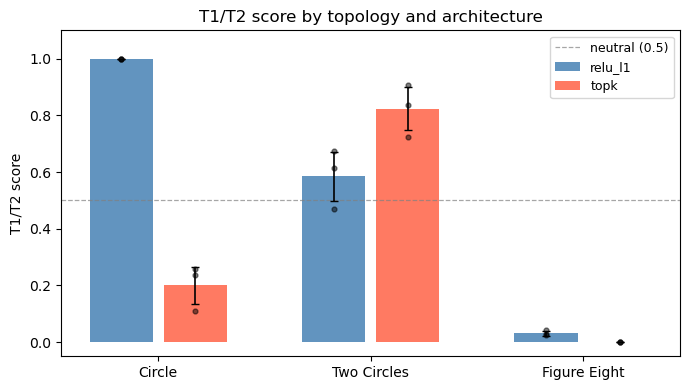

In [6]:
from sae_topology.analysis import plot_score_vs_topology
fig = plot_score_vs_topology(stage3_results)
plt.show()